# EARA — Deezer Europe Reproduction and Robustness Experiments

This notebook reproduces the experimental pipeline used for the Twitter experiment on the **Deezer Europe** network.

It includes:

1. Dataset integrity and graph statistics
2. Full-graph connectivity
3. Random 15,000-node sampling diagnostic
4. Connected-growth 15,000-node experimental graph
5. Degree comparison
6. Synthetic temporal traffic generation and validation
7. Synthetic attack generation
8. Attack-surface analysis
9. Edge-level disorder calculation
10. Capped EARA weight construction
11. Baseline shortest-path vs EARA routing
12. Attack-edge exposure
13. Weighted-cost comparison
14. Path-disorder comparison
15. Capped vs uncapped EARA
16. Five-seed robustness experiment
17. Export of result tables

The experiment keeps the core parameters consistent with the Twitter experiment.


In [6]:
# Cell 1 — Imports and configuration

import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_PATH = Path("deezer_europe/deezer_europe_edges.csv")

SAMPLE_SIZE = 15000

TIMESTEPS = 50
TRAFFIC_MU = 10
TRAFFIC_SIGMA = 2

ATTACK_TARGETS = 5
ATTACK_STRENGTH = 40
ATTACK_DURATION = 8
ATTACK_START_MIN = 10
ATTACK_START_MAX = 30
ATTACK_START = 26

NUM_ROUTES = 100
ROUTING_SEED = 42

ROBUSTNESS_SEEDS = [42, 43, 44, 45, 46]

print("Dataset:", DATA_PATH)
print("Exists:", DATA_PATH.exists())


Dataset: deezer_europe\deezer_europe_edges.csv
Exists: True


In [7]:
# Cell 2 — Load edge list

edges = pd.read_csv(DATA_PATH)

src_col, dst_col = edges.columns[:2]
edges = edges[[src_col, dst_col]].copy()
edges.columns = ["source", "target"]

edges["source"] = edges["source"].astype(np.int64)
edges["target"] = edges["target"].astype(np.int64)

print("Rows:", len(edges))
print(edges.head(10))


Rows: 92752
   source  target
0       0   14270
1       0   16976
2       0   12029
3       0    3001
4       0   14581
5       0   14145
6       0   25564
7       1   26065
8       1    2514
9       1   16675


In [8]:
# Cell 3 — Dataset integrity checks

self_loops = int((edges["source"] == edges["target"]).sum())

canonical = pd.DataFrame({
    "u": np.minimum(edges["source"].values, edges["target"].values),
    "v": np.maximum(edges["source"].values, edges["target"].values)
})
duplicate_undirected_edges = int(canonical.duplicated().sum())

print("Self-loops:", self_loops)
print("Duplicate undirected edge rows:", duplicate_undirected_edges)
print("Unique nodes:", len(set(edges["source"]) | set(edges["target"])))
print("Edge rows:", len(edges))

assert self_loops == 0
assert duplicate_undirected_edges == 0


Self-loops: 0
Duplicate undirected edge rows: 0
Unique nodes: 28281
Edge rows: 92752


In [9]:
# Cell 4 — Build the full Deezer graph

G = nx.Graph()
G.add_edges_from(edges.itertuples(index=False, name=None))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))
print("Average degree:", np.mean([d for _, d in G.degree()]))
print("Median degree:", np.median([d for _, d in G.degree()]))
print("Maximum degree:", max(dict(G.degree()).values()))
print("Degree std:", np.std([d for _, d in G.degree()]))
print("Connected:", nx.is_connected(G))


Nodes: 28281
Edges: 92752
Density: 0.00023194184729358083
Average degree: 6.559315441462466
Median degree: 4.0
Maximum degree: 172
Degree std: 7.945997919531553
Connected: True


In [10]:
# Cell 5 — Full graph connectivity

components = list(nx.connected_components(G))

component_sizes = sorted((len(c) for c in components), reverse=True)

print("Connected components:", len(components))
print("Largest component:", component_sizes[0])
print("Smallest component:", component_sizes[-1])


Connected components: 1
Largest component: 28281
Smallest component: 28281


Degree quantiles:
0.00      1.0
0.25      2.0
0.50      4.0
0.75      8.0
0.90     15.0
0.95     21.0
0.99     38.0
1.00    172.0
dtype: float64


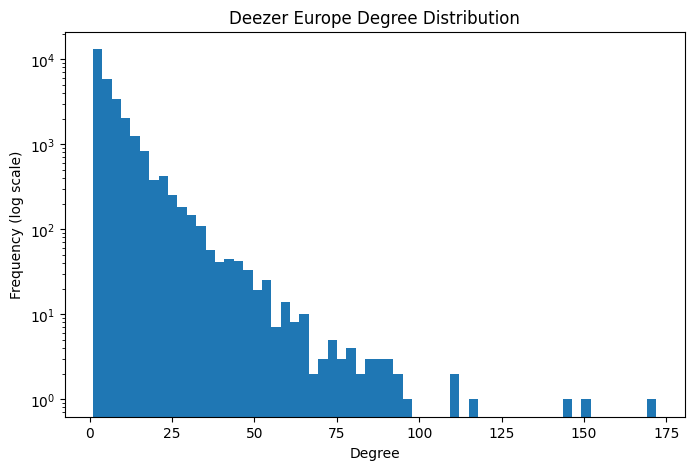

In [11]:
# Cell 6 — Full degree distribution

degrees = np.array([d for _, d in G.degree()])

print("Degree quantiles:")
print(pd.Series(degrees).quantile([0, .25, .5, .75, .9, .95, .99, 1]))

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=60)
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Deezer Europe Degree Distribution")
plt.show()


In [12]:
# Cell 7 — Random 15,000-node sampling diagnostic

random.seed(SEED)
random_nodes = random.sample(list(G.nodes()), SAMPLE_SIZE)
G_random = G.subgraph(random_nodes).copy()

random_components = list(nx.connected_components(G_random))
random_component_sizes = sorted(
    (len(c) for c in random_components), reverse=True
)

print("Random sample nodes:", G_random.number_of_nodes())
print("Random sample edges:", G_random.number_of_edges())
print("Random sample connected:", nx.is_connected(G_random))
print("Random sample components:", len(random_components))
print("Largest random component:", random_component_sizes[0])
print("Smallest random component:", random_component_sizes[-1])


Random sample nodes: 15000
Random sample edges: 25432
Random sample connected: False
Random sample components: 2567
Largest random component: 11785
Smallest random component: 1


In [13]:
# Cell 8 — Connected-growth sampling

def connected_growth_sample(G, sample_size, seed):
    rng = random.Random(seed)

    start_node = rng.choice(list(G.nodes()))
    sampled_nodes = {start_node}
    frontier = set(G.neighbors(start_node))

    while len(sampled_nodes) < sample_size:
        if not frontier:
            raise RuntimeError("Frontier exhausted before reaching requested sample size.")

        node = rng.choice(tuple(frontier))
        sampled_nodes.add(node)
        frontier.remove(node)

        for neighbor in G.neighbors(node):
            if neighbor not in sampled_nodes:
                frontier.add(neighbor)

    return G.subgraph(sampled_nodes).copy()

G_connected = connected_growth_sample(G, SAMPLE_SIZE, SEED)

print("Nodes:", G_connected.number_of_nodes())
print("Edges:", G_connected.number_of_edges())
print("Connected:", nx.is_connected(G_connected))


Nodes: 15000
Edges: 44754
Connected: True


In [14]:
# Cell 9 — Full vs experimental degree comparison

full_deg = np.array([d for _, d in G.degree()])
exp_deg = np.array([d for _, d in G_connected.degree()])

degree_comparison = pd.DataFrame({
    "Metric": ["Mean", "Median", "Maximum", "Std"],
    "Full graph": [
        full_deg.mean(),
        np.median(full_deg),
        full_deg.max(),
        full_deg.std()
    ],
    "Experimental graph": [
        exp_deg.mean(),
        np.median(exp_deg),
        exp_deg.max(),
        exp_deg.std()
    ]
})

degree_comparison


,Metric,Full graph,Experimental graph
0,Mean,6.559315,5.967200
1,Median,4.000000,4.000000
2,Maximum,172.000000,140.000000
3,Std,7.945998,6.670282


In [15]:
# Cell 10 — Edge-key helper

def edge_key(u, v):
    return (u, v) if u <= v else (v, u)


In [16]:
# Cell 11 — Generate baseline temporal traffic

np.random.seed(SEED)

traffic = {}

for u, v in G_connected.edges():
    traffic[edge_key(u, v)] = np.random.normal(
        loc=TRAFFIC_MU,
        scale=TRAFFIC_SIGMA,
        size=TIMESTEPS
    )

all_values = np.concatenate(list(traffic.values()))

print("Observations:", len(all_values))
print("Expected mean:", TRAFFIC_MU)
print("Observed mean:", all_values.mean())
print("Expected std:", TRAFFIC_SIGMA)
print("Observed std:", all_values.std())
print("Minimum:", all_values.min())
print("Maximum:", all_values.max())


Observations: 2237700
Expected mean: 10
Observed mean: 9.998683611035897
Expected std: 2
Observed std: 2.001393516335065
Minimum: 0.3411279829776852
Maximum: 19.65524545865483


In [17]:
# Cell 12 — Clean baseline traffic copy

baseline_traffic = {
    edge: values.copy()
    for edge, values in traffic.items()
}

print("Baseline traffic edges:", len(baseline_traffic))


Baseline traffic edges: 44754


In [18]:
# Cell 13 — Attack configuration

degree_sorted = sorted(
    G_connected.degree(),
    key=lambda x: x[1],
    reverse=True
)

attack_targets = degree_sorted[:ATTACK_TARGETS]
attack_nodes = [node for node, degree in attack_targets]

print("Attack targets:")
for node, degree in attack_targets:
    print(node, "degree =", degree)


Attack targets:
867 degree = 140
1878 degree = 116
396 degree = 109
5989 degree = 82
21798 degree = 78


In [19]:
# Cell 14 — Attack surface

attack_edges = set()

for node in attack_nodes:
    for neighbor in G_connected.neighbors(node):
        attack_edges.add(edge_key(node, neighbor))

print("Unique attack edges:", len(attack_edges))
print("Total graph edges:", G_connected.number_of_edges())
print(
    "Attack-edge percentage:",
    100 * len(attack_edges) / G_connected.number_of_edges()
)


Unique attack edges: 524
Total graph edges: 44754
Attack-edge percentage: 1.170845064128346


In [20]:
# Cell 15 — Controlled attack injection

ATTACK_START = 26
ATTACK_END = ATTACK_START + ATTACK_DURATION

traffic = {
    edge: values.copy()
    for edge, values in baseline_traffic.items()
}

np.random.seed(SEED)

for edge in attack_edges:
    for t in range(ATTACK_START, ATTACK_END):
        traffic[edge][t] += ATTACK_STRENGTH * np.random.uniform(0.7, 1.2)

print("Attack interval:", ATTACK_START, "to", ATTACK_END - 1)
print("Duration:", ATTACK_END - ATTACK_START)


Attack interval: 26 to 33
Duration: 8


In [21]:
# Cell 16 — Attack validation

attacked_values = np.concatenate([
    traffic[e] for e in attack_edges
])

unaffected_edges = set(traffic) - attack_edges
unaffected_values = np.concatenate([
    traffic[e] for e in unaffected_edges
])

attack_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Variance",
        "Std",
        "Mean absolute temporal change"
    ],
    "Attacked": [
        attacked_values.mean(),
        attacked_values.var(),
        attacked_values.std(),
        np.mean([
            np.mean(np.abs(np.diff(traffic[e])))
            for e in attack_edges
        ])
    ],
    "Unaffected": [
        unaffected_values.mean(),
        unaffected_values.var(),
        unaffected_values.std(),
        np.mean([
            np.mean(np.abs(np.diff(traffic[e])))
            for e in unaffected_edges
        ])
    ]
})

attack_stats


,Metric,Attacked,Unaffected
0,Mean,16.070540,9.998683
1,Variance,203.007680,4.005781
2,Std,14.248076,2.001445
3,Mean absolute temporal change,4.387348,2.260434


In [22]:
# Cell 17 — Edge-level disorder

disorder = {}
edge_variance = {}
edge_temporal_change = {}

for edge, loads in traffic.items():
    variance = np.var(loads)
    temporal_change = np.mean(np.abs(np.diff(loads)))

    H = np.log(
        1 + variance + 0.5 * temporal_change
    )

    edge_variance[edge] = variance
    edge_temporal_change[edge] = temporal_change
    disorder[edge] = H

attacked_disorder = np.array([disorder[e] for e in attack_edges])
unaffected_disorder = np.array([
    disorder[e] for e in unaffected_edges
])

print("Mean attacked disorder:", attacked_disorder.mean())
print("Mean unaffected disorder:", unaffected_disorder.mean())
print("Median attacked disorder:", np.median(attacked_disorder))
print("Median unaffected disorder:", np.median(unaffected_disorder))
print("Maximum attacked disorder:", attacked_disorder.max())
print("Maximum unaffected disorder:", unaffected_disorder.max())


Mean attacked disorder: 5.321650083699338
Mean unaffected disorder: 1.7898387610812074
Median attacked disorder: 5.322912406369458
Median unaffected disorder: 1.792088676192773
Maximum attacked disorder: 5.599131992037455
Maximum unaffected disorder: 2.40814582581952


In [23]:
# Cell 18 — Raw disorder distribution and cap analysis

raw_weights = {
    e: 1.0 + disorder[e]
    for e in disorder
}

capped_weights = {
    e: min(raw_weights[e], 5.0)
    for e in raw_weights
}

raw_weight_values = np.array(list(raw_weights.values()))
capped_weight_values = np.array(list(capped_weights.values()))

cap_affected = sum(
    raw_weights[e] > 5.0
    for e in raw_weights
)

print("Raw weight min:", raw_weight_values.min())
print("Raw weight max:", raw_weight_values.max())
print("Capped weight max:", capped_weight_values.max())
print("Edges affected by cap:", cap_affected)
print(
    "Percentage affected:",
    100 * cap_affected / len(raw_weights)
)


Raw weight min: 2.142478382751142
Raw weight max: 6.599131992037455
Capped weight max: 5.0
Edges affected by cap: 524
Percentage affected: 1.170845064128346


In [24]:
# Cell 19 — Assign EARA weights

G_eara = G_connected.copy()

nx.set_edge_attributes(
    G_eara,
    capped_weights,
    "weight"
)

print("EARA weighted graph created.")


EARA weighted graph created.


In [25]:
# Cell 20 — Generate route pairs

random.seed(ROUTING_SEED)

nodes = list(G_connected.nodes())

route_pairs = []
seen = set()

while len(route_pairs) < NUM_ROUTES:
    source, target = random.sample(nodes, 2)

    if (source, target) not in seen and (target, source) not in seen:
        route_pairs.append((source, target))
        seen.add((source, target))

print("Route pairs:", len(route_pairs))
print("First 10:")
for pair in route_pairs[:10]:
    print(pair)


Route pairs: 100
First 10:
(16667, 4456)
(9065, 20881)
(8208, 941)
(14345, 513)
(14680, 378)
(10515, 7110)
(22341, 10880)
(17142, 17688)
(2021, 23050)
(106, 5288)


In [26]:
# Cell 21 — Routing experiment

def path_edges(path):
    return [
        edge_key(path[i], path[i + 1])
        for i in range(len(path) - 1)
    ]

route_results = []

for source, target in route_pairs:

    baseline_path = nx.shortest_path(
        G_connected,
        source,
        target
    )

    eara_path = nx.shortest_path(
        G_eara,
        source,
        target,
        weight="weight"
    )

    baseline_edges = path_edges(baseline_path)
    eara_edges = path_edges(eara_path)

    baseline_attack_edges = sum(
        e in attack_edges for e in baseline_edges
    )

    eara_attack_edges = sum(
        e in attack_edges for e in eara_edges
    )

    route_results.append({
        "source": source,
        "target": target,

        "baseline_hops": len(baseline_path) - 1,
        "eara_hops": len(eara_path) - 1,

        "baseline_weighted_cost": sum(
            capped_weights[e] for e in baseline_edges
        ),

        "eara_weighted_cost": sum(
            capped_weights[e] for e in eara_edges
        ),

        "baseline_attack_edges": baseline_attack_edges,
        "eara_attack_edges": eara_attack_edges,

        "baseline_attack_fraction": (
            baseline_attack_edges / max(1, len(baseline_edges))
        ),

        "eara_attack_fraction": (
            eara_attack_edges / max(1, len(eara_edges))
        ),

        "baseline_path_disorder": sum(
            disorder[e] for e in baseline_edges
        ),

        "eara_path_disorder": sum(
            disorder[e] for e in eara_edges
        )
    })

results = pd.DataFrame(route_results)

results.head()


,source,target,baseline_hops,eara_hops,baseline_weighted_cost,eara_weighted_cost,baseline_attack_edges,eara_attack_edges,baseline_attack_fraction,eara_attack_fraction,baseline_path_disorder,eara_path_disorder
0,16667,4456,5,5,14.236662,13.549971,0,0,0.0,0.0,9.236662,8.549971
1,9065,20881,5,5,14.062448,13.954702,0,0,0.0,0.0,9.062448,8.954702
2,8208,941,5,5,14.398819,13.916674,0,0,0.0,0.0,9.398819,8.916674
3,14345,513,9,9,25.136743,24.760263,0,0,0.0,0.0,16.136743,15.760263
4,14680,378,5,5,14.059649,13.479912,0,0,0.0,0.0,9.059649,8.479912


In [27]:
# Cell 22 — Primary routing summary

summary = pd.DataFrame({
    "Metric": [
        "Mean hops",
        "Median hops",
        "Mean weighted cost",
        "Median weighted cost",
        "Mean attack-edge fraction",
        "Total attack-edge traversals",
        "Routes using attack edges",
        "Mean path disorder"
    ],
    "Baseline": [
        results.baseline_hops.mean(),
        results.baseline_hops.median(),
        results.baseline_weighted_cost.mean(),
        results.baseline_weighted_cost.median(),
        results.baseline_attack_fraction.mean(),
        results.baseline_attack_edges.sum(),
        (results.baseline_attack_edges > 0).sum(),
        results.baseline_path_disorder.mean()
    ],
    "EARA": [
        results.eara_hops.mean(),
        results.eara_hops.median(),
        results.eara_weighted_cost.mean(),
        results.eara_weighted_cost.median(),
        results.eara_attack_fraction.mean(),
        results.eara_attack_edges.sum(),
        (results.eara_attack_edges > 0).sum(),
        results.eara_path_disorder.mean()
    ]
})

summary


,Metric,Baseline,EARA
0,Mean hops,6.420000,6.430000
1,Median hops,6.000000,6.000000
2,Mean weighted cost,18.255282,17.743750
3,Median weighted cost,17.206437,16.700668
4,Mean attack-edge fraction,0.027524,0.006500
5,Total attack-edge traversals,16.000000,4.000000
6,Routes using attack edges,8.000000,2.000000
7,Mean path disorder,12.050692,11.369097


In [28]:
# Cell 23 — Percentage changes

attack_fraction_reduction = (
    100 * (
        1 -
        results.eara_attack_fraction.mean()
        / results.baseline_attack_fraction.mean()
    )
)

attack_traversal_reduction = (
    100 * (
        1 -
        results.eara_attack_edges.sum()
        / results.baseline_attack_edges.sum()
    )
)

weighted_cost_reduction = (
    100 * (
        1 -
        results.eara_weighted_cost.mean()
        / results.baseline_weighted_cost.mean()
    )
)

path_disorder_reduction = (
    100 * (
        1 -
        results.eara_path_disorder.mean()
        / results.baseline_path_disorder.mean()
    )
)

print("Attack-edge fraction reduction:", attack_fraction_reduction, "%")
print("Attack-edge traversal reduction:", attack_traversal_reduction, "%")
print("Weighted-cost reduction:", weighted_cost_reduction, "%")
print("Path-disorder reduction:", path_disorder_reduction, "%")
print(
    "Mean hop increase:",
    results.eara_hops.mean() - results.baseline_hops.mean()
)


Attack-edge fraction reduction: 76.3840830449827 %
Attack-edge traversal reduction: 75.0 %
Weighted-cost reduction: 2.802106172231311 %
Path-disorder reduction: 5.656067511860607 %
Mean hop increase: 0.009999999999999787


In [29]:
# Cell 24 — Longer EARA routes

longer = results[
    results.eara_hops > results.baseline_hops
].copy()

print("Number of longer EARA routes:", len(longer))

longer[
    [
        "source", "target",
        "baseline_hops", "eara_hops",
        "baseline_attack_edges", "eara_attack_edges",
        "baseline_weighted_cost", "eara_weighted_cost"
    ]
]


Number of longer EARA routes: 1


,source,target,baseline_hops,eara_hops,baseline_attack_edges,eara_attack_edges,baseline_weighted_cost,eara_weighted_cost
85,5937,6620,5,6,2,0,18.622919,16.794652


In [30]:
# Cell 25 — Edge-weight separation

attacked_weights = np.array([
    capped_weights[e] for e in attack_edges
])

unaffected_weights = np.array([
    capped_weights[e] for e in unaffected_edges
])

weight_separation = pd.DataFrame({
    "Metric": ["Mean", "Median", "Minimum", "Maximum"],
    "Attacked": [
        attacked_weights.mean(),
        np.median(attacked_weights),
        attacked_weights.min(),
        attacked_weights.max()
    ],
    "Unaffected": [
        unaffected_weights.mean(),
        np.median(unaffected_weights),
        unaffected_weights.min(),
        unaffected_weights.max()
    ]
})

weight_separation


,Metric,Attacked,Unaffected
0,Mean,5.0,2.789839
1,Median,5.0,2.792089
2,Minimum,5.0,2.142478
3,Maximum,5.0,3.408146


In [31]:
# Cell 26 — Uncapped EARA

G_uncapped = G_connected.copy()

nx.set_edge_attributes(
    G_uncapped,
    raw_weights,
    "weight"
)

uncapped_rows = []

for source, target in route_pairs:

    capped_path = nx.shortest_path(
        G_eara, source, target, weight="weight"
    )

    uncapped_path = nx.shortest_path(
        G_uncapped, source, target, weight="weight"
    )

    capped_edges = path_edges(capped_path)
    uncapped_edges = path_edges(uncapped_path)

    uncapped_rows.append({
        "source": source,
        "target": target,
        "capped_hops": len(capped_path) - 1,
        "uncapped_hops": len(uncapped_path) - 1,
        "capped_attack_fraction": (
            sum(e in attack_edges for e in capped_edges)
            / max(1, len(capped_edges))
        ),
        "uncapped_attack_fraction": (
            sum(e in attack_edges for e in uncapped_edges)
            / max(1, len(uncapped_edges))
        ),
        "capped_cost": sum(capped_weights[e] for e in capped_edges),
        "uncapped_cost": sum(raw_weights[e] for e in uncapped_edges)
    })

uncapped_results = pd.DataFrame(uncapped_rows)

print(
    "Same route:",
    (
        (uncapped_results.capped_hops == uncapped_results.uncapped_hops)
        & (
            uncapped_results.capped_attack_fraction
            == uncapped_results.uncapped_attack_fraction
        )
    ).sum(),
    "/",
    len(uncapped_results)
)

print("Mean capped hops:", uncapped_results.capped_hops.mean())
print("Mean uncapped hops:", uncapped_results.uncapped_hops.mean())
print(
    "Mean capped attack fraction:",
    uncapped_results.capped_attack_fraction.mean()
)
print(
    "Mean uncapped attack fraction:",
    uncapped_results.uncapped_attack_fraction.mean()
)


Same route: 99 / 100
Mean capped hops: 6.43
Mean uncapped hops: 6.45
Mean capped attack fraction: 0.006500000000000001
Mean uncapped attack fraction: 0.0025


In [32]:
# Cell 27 — Five-seed robustness experiment

def run_seed_experiment(graph, seed, route_seed):
    rng_np = np.random.default_rng(seed)
    route_rng = random.Random(route_seed)

    # Fresh traffic realization
    traffic_seeded = {}
    for u, v in graph.edges():
        traffic_seeded[edge_key(u, v)] = rng_np.normal(
            TRAFFIC_MU,
            TRAFFIC_SIGMA,
            TIMESTEPS
        )

    # Fixed attack target nodes, as in the main Deezer experiment
    attack_edges_seeded = set()
    for node in attack_nodes:
        for nbr in graph.neighbors(node):
            attack_edges_seeded.add(edge_key(node, nbr))

    # Fresh attack realization
    for edge in attack_edges_seeded:
        for t in range(ATTACK_START, ATTACK_START + ATTACK_DURATION):
            traffic_seeded[edge][t] += (
                ATTACK_STRENGTH * rng_np.uniform(0.7, 1.2)
            )

    disorder_seeded = {}
    weights_seeded = {}

    for edge, loads in traffic_seeded.items():
        variance = np.var(loads)
        temporal = np.mean(np.abs(np.diff(loads)))
        H = np.log(1 + variance + 0.5 * temporal)

        disorder_seeded[edge] = H
        weights_seeded[edge] = min(1 + H, 5)

    G_seeded = graph.copy()
    nx.set_edge_attributes(
        G_seeded,
        weights_seeded,
        "weight"
    )

    # Fresh route pairs
    nodes_seeded = list(graph.nodes())
    pairs = []
    seen_pairs = set()

    while len(pairs) < NUM_ROUTES:
        s, t = route_rng.sample(nodes_seeded, 2)

        if (s, t) not in seen_pairs and (t, s) not in seen_pairs:
            pairs.append((s, t))
            seen_pairs.add((s, t))

    rows = []

    for s, t in pairs:
        baseline_path = nx.shortest_path(graph, s, t)
        eara_path = nx.shortest_path(
            G_seeded, s, t, weight="weight"
        )

        bp_edges = path_edges(baseline_path)
        ep_edges = path_edges(eara_path)

        rows.append({
            "seed": seed,
            "baseline_hops": len(baseline_path) - 1,
            "eara_hops": len(eara_path) - 1,

            "baseline_attack_fraction":
                sum(e in attack_edges_seeded for e in bp_edges)
                / max(1, len(bp_edges)),

            "eara_attack_fraction":
                sum(e in attack_edges_seeded for e in ep_edges)
                / max(1, len(ep_edges)),

            "baseline_attack_edges":
                sum(e in attack_edges_seeded for e in bp_edges),

            "eara_attack_edges":
                sum(e in attack_edges_seeded for e in ep_edges),

            "baseline_weighted_cost":
                sum(weights_seeded[e] for e in bp_edges),

            "eara_weighted_cost":
                sum(weights_seeded[e] for e in ep_edges),

            "baseline_path_disorder":
                sum(disorder_seeded[e] for e in bp_edges),

            "eara_path_disorder":
                sum(disorder_seeded[e] for e in ep_edges)
        })

    return pd.DataFrame(rows)

robustness_runs = []

for seed in ROBUSTNESS_SEEDS:
    run_df = run_seed_experiment(
        G_connected,
        seed=seed,
        route_seed=seed
    )
    robustness_runs.append(run_df)

robustness_routes = pd.concat(
    robustness_runs,
    ignore_index=True
)

print("Robustness observations:", len(robustness_routes))


Robustness observations: 500


In [33]:
# Cell 28 — Per-seed robustness summary

per_seed = robustness_routes.groupby("seed").agg(
    baseline_mean_hops=("baseline_hops", "mean"),
    eara_mean_hops=("eara_hops", "mean"),

    baseline_attack_fraction=("baseline_attack_fraction", "mean"),
    eara_attack_fraction=("eara_attack_fraction", "mean"),

    baseline_attack_traversals=("baseline_attack_edges", "sum"),
    eara_attack_traversals=("eara_attack_edges", "sum"),

    baseline_weighted_cost=("baseline_weighted_cost", "mean"),
    eara_weighted_cost=("eara_weighted_cost", "mean"),

    baseline_path_disorder=("baseline_path_disorder", "mean"),
    eara_path_disorder=("eara_path_disorder", "mean")
).reset_index()

per_seed["hop_delta"] = (
    per_seed.eara_mean_hops -
    per_seed.baseline_mean_hops
)

per_seed["attack_fraction_reduction_pct"] = 100 * (
    1 -
    per_seed.eara_attack_fraction /
    per_seed.baseline_attack_fraction
)

per_seed["attack_traversal_reduction_pct"] = 100 * (
    1 -
    per_seed.eara_attack_traversals /
    per_seed.baseline_attack_traversals
)

per_seed["weighted_cost_reduction_pct"] = 100 * (
    1 -
    per_seed.eara_weighted_cost /
    per_seed.baseline_weighted_cost
)

per_seed["path_disorder_reduction_pct"] = 100 * (
    1 -
    per_seed.eara_path_disorder /
    per_seed.baseline_path_disorder
)

per_seed.round(4)


,seed,baseline_mean_hops,eara_mean_hops,baseline_attack_fraction,eara_attack_fraction,baseline_attack_traversals,eara_attack_traversals,baseline_weighted_cost,eara_weighted_cost,baseline_path_disorder,eara_path_disorder,hop_delta,attack_fraction_reduction_pct,attack_traversal_reduction_pct,weighted_cost_reduction_pct,path_disorder_reduction_pct
0,42,6.42,6.43,0.0275,0.0065,16,4,18.2991,17.7811,12.0939,11.4057,0.01,76.3841,75.0000,2.8307,5.6900
1,43,6.47,6.50,0.0390,0.0142,22,6,18.5262,17.9697,12.3511,11.5476,0.03,63.7195,72.7273,3.0041,6.5052
2,44,6.06,6.12,0.0590,0.0025,29,2,17.5940,16.8638,11.9211,10.7713,0.06,95.7644,93.1034,4.1502,9.6447
3,45,6.12,6.18,0.0715,0.0157,38,6,17.9591,17.1873,12.3295,11.0851,0.06,78.0959,84.2105,4.2971,10.0926
4,46,6.15,6.16,0.0389,0.0183,18,6,17.5841,17.1084,11.6748,11.0267,0.01,52.8475,66.6667,2.7057,5.5507


In [34]:
# Cell 29 — Robustness mean ± SD

robustness_summary = pd.DataFrame({
    "Metric": [
        "Mean hops",
        "Attack-edge fraction",
        "Mean weighted cost",
        "Mean path disorder"
    ],

    "Baseline mean": [
        per_seed.baseline_mean_hops.mean(),
        per_seed.baseline_attack_fraction.mean(),
        per_seed.baseline_weighted_cost.mean(),
        per_seed.baseline_path_disorder.mean()
    ],

    "Baseline SD": [
        per_seed.baseline_mean_hops.std(ddof=1),
        per_seed.baseline_attack_fraction.std(ddof=1),
        per_seed.baseline_weighted_cost.std(ddof=1),
        per_seed.baseline_path_disorder.std(ddof=1)
    ],

    "EARA mean": [
        per_seed.eara_mean_hops.mean(),
        per_seed.eara_attack_fraction.mean(),
        per_seed.eara_weighted_cost.mean(),
        per_seed.eara_path_disorder.mean()
    ],

    "EARA SD": [
        per_seed.eara_mean_hops.std(ddof=1),
        per_seed.eara_attack_fraction.std(ddof=1),
        per_seed.eara_weighted_cost.std(ddof=1),
        per_seed.eara_path_disorder.std(ddof=1)
    ]
})

robustness_summary["Relative change (%)"] = [
    100 * (
        1 -
        robustness_summary.loc[0, "EARA mean"]
        / robustness_summary.loc[0, "Baseline mean"]
    ),
    100 * (
        1 -
        robustness_summary.loc[1, "EARA mean"]
        / robustness_summary.loc[1, "Baseline mean"]
    ),
    100 * (
        1 -
        robustness_summary.loc[2, "EARA mean"]
        / robustness_summary.loc[2, "Baseline mean"]
    ),
    100 * (
        1 -
        robustness_summary.loc[3, "EARA mean"]
        / robustness_summary.loc[3, "Baseline mean"]
    )
]

robustness_summary.round(4)


,Metric,Baseline mean,Baseline SD,EARA mean,EARA SD,Relative change (%)
0,Mean hops,6.2440,0.1872,6.2780,0.1738,-0.5445
1,Attack-edge fraction,0.0472,0.0177,0.0114,0.0067,75.7768
2,Mean weighted cost,17.9925,0.4200,17.3821,0.4706,3.3928
3,Mean path disorder,12.0741,0.2851,11.1673,0.3102,7.5099


In [35]:
# Cell 30 — Robustness: did every seed reduce attack exposure?

print(
    "Seeds with lower attack-edge fraction:",
    (
        per_seed.eara_attack_fraction
        < per_seed.baseline_attack_fraction
    ).sum(),
    "/",
    len(per_seed)
)

print(
    "Seeds with lower path disorder:",
    (
        per_seed.eara_path_disorder
        < per_seed.baseline_path_disorder
    ).sum(),
    "/",
    len(per_seed)
)

print(
    "Seeds with non-increasing hop count:",
    (
        per_seed.eara_mean_hops
        <= per_seed.baseline_mean_hops
    ).sum(),
    "/",
    len(per_seed)
)


Seeds with lower attack-edge fraction: 5 / 5
Seeds with lower path disorder: 5 / 5
Seeds with non-increasing hop count: 0 / 5


In [36]:
# Cell 31 — Export results

OUTPUT_DIR = Path("EARA_Deezer_results")
OUTPUT_DIR.mkdir(exist_ok=True)

edges.to_csv(OUTPUT_DIR / "deezer_loaded_edges.csv", index=False)
degree_comparison.to_csv(OUTPUT_DIR / "degree_comparison.csv", index=False)
attack_stats.to_csv(OUTPUT_DIR / "attack_validation.csv", index=False)
weight_separation.to_csv(OUTPUT_DIR / "weight_separation.csv", index=False)
summary.to_csv(OUTPUT_DIR / "primary_routing_summary.csv", index=False)
results.to_csv(OUTPUT_DIR / "primary_route_results.csv", index=False)
uncapped_results.to_csv(OUTPUT_DIR / "capped_vs_uncapped.csv", index=False)
per_seed.to_csv(OUTPUT_DIR / "robustness_per_seed.csv", index=False)
robustness_summary.to_csv(OUTPUT_DIR / "robustness_mean_sd.csv", index=False)
robustness_routes.to_csv(OUTPUT_DIR / "robustness_all_routes.csv", index=False)

print("Results exported to:", OUTPUT_DIR)


Results exported to: EARA_Deezer_results
